# 05 - Drift and retraining cadence

*This notebook is a thin view: it renders artifacts persisted by the pipeline (`make data features train evaluate figures`). No result is computed here.*

In [1]:
import json, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import pandas as pd
from IPython.display import Image, display

RESULTS = Path.cwd().parent / "results" / "metrics"
FIGURES = Path.cwd().parent / "reports" / "figures"

def load(name):
    with open(RESULTS / f"{name}.json") as fh:
        return json.load(fh)

def fig(name):
    display(Image(str(FIGURES / f"{name}.png"), width=880))


In [2]:
drift = load('stage5_drift')
pd.DataFrame(drift['weekly']['static']).round(4).head(10)

,week,month,n,fraud_rate,tpr_at_5fpr,pr_auc,savings,brier
0,17,4,20524,0.0356,0.7825,0.6978,0.5916,0.0163
1,18,4,19622,0.0353,0.7100,0.5781,0.4381,0.0209
2,19,4,18630,0.0346,0.6615,0.5750,0.5093,0.0205
3,20,4,18460,0.0359,0.6184,0.4881,0.3544,0.0243
4,21,5,20378,0.0317,0.6698,0.5689,0.3125,0.0191
5,22,5,20740,0.0285,0.6751,0.5338,0.3415,0.0183
6,23,5,20944,0.0325,0.6079,0.4711,0.2823,0.0233
7,24,5,20206,0.0367,0.6505,0.5413,0.3650,0.0233
8,25,5,20435,0.0418,0.6515,0.5609,0.4705,0.0255


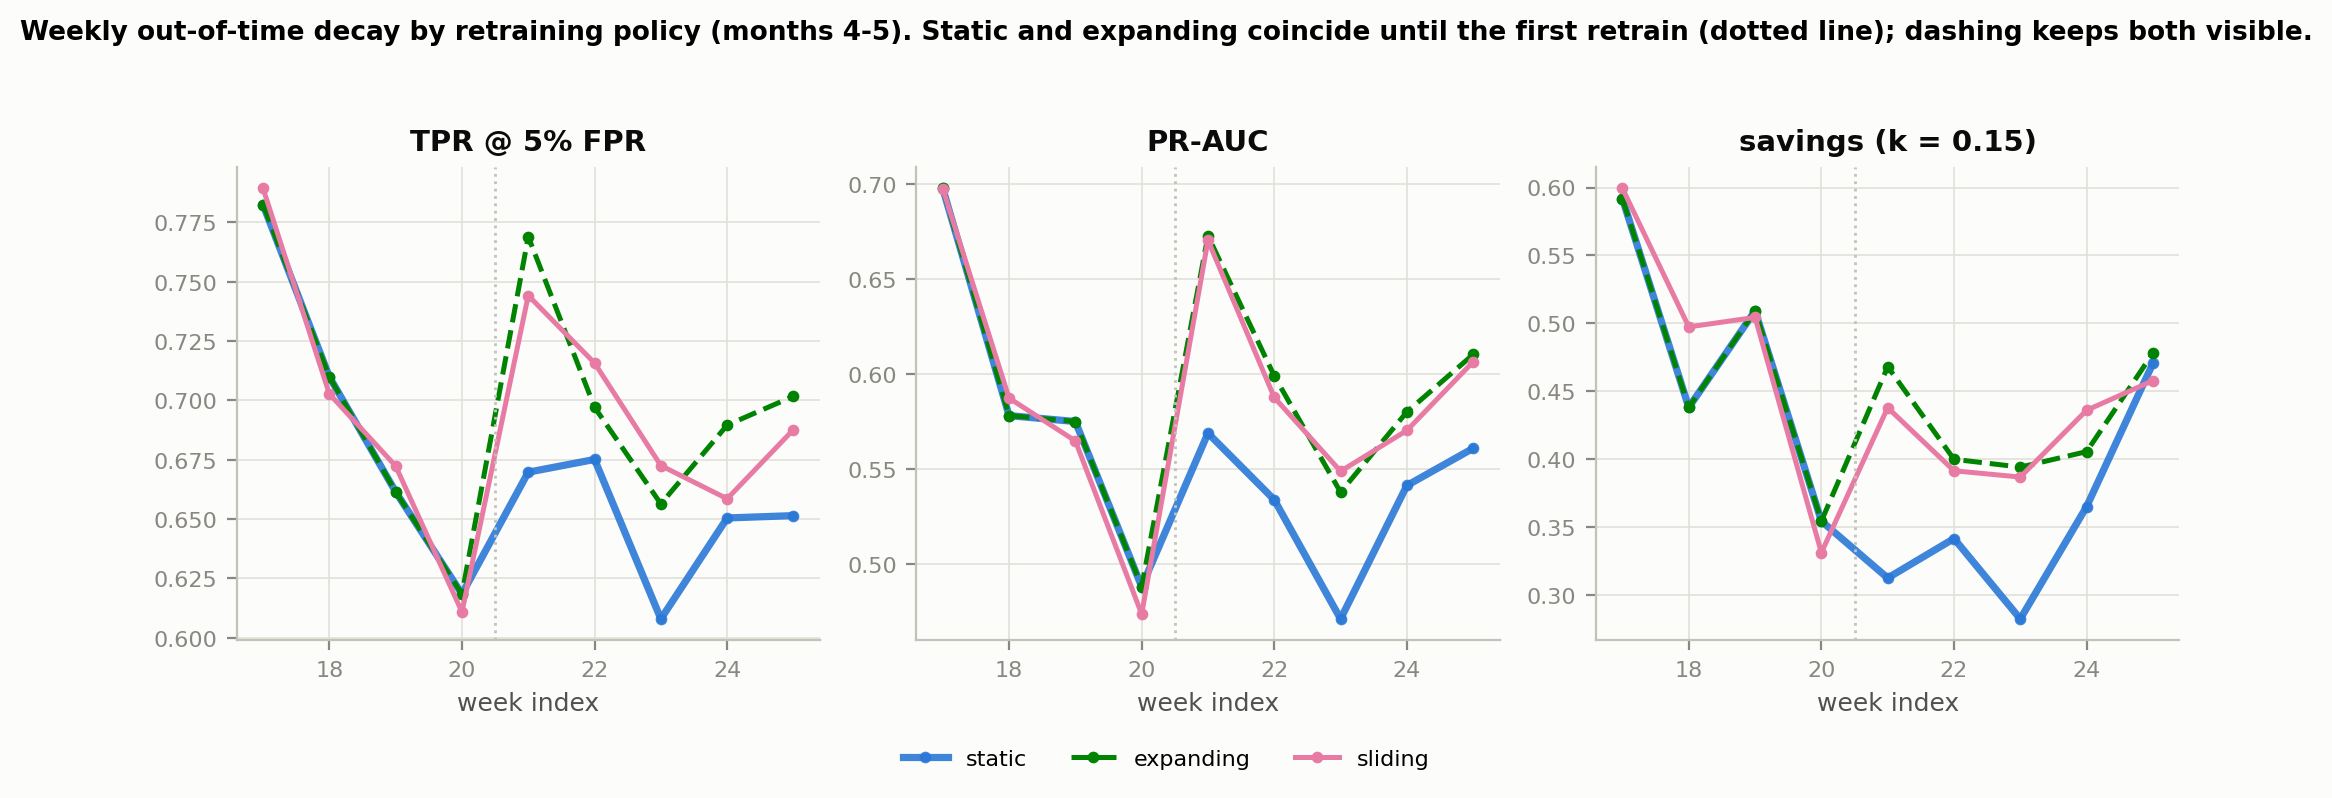

In [3]:
fig('figure_07_decay_curves')

In [4]:
psi = load('stage5_psi')
pd.Series(psi['max_psi_per_feature']).sort_values(ascending=False).head(10).round(3)

id_31                        1.363
card1_past_count             0.377
card1_addr1_past_count       0.367
card1_past_amt_mean          0.169
D15                          0.152
DeviceInfo                   0.134
card1_addr1_past_amt_mean    0.103
V70                          0.083
D2                           0.069
card1_amt_ratio              0.062
dtype: float64

In [5]:
adv = load('stage5_adversarial')
pd.DataFrame(adv['internal_oot'])[['tag','cv_auc_mean','cv_auc_sd']]

,tag,cv_auc_mean,cv_auc_sd
0,train_vs_oot_full_features,0.964021,0.000273
1,train_vs_oot_excl_causal_aggregates,0.898612,0.001232


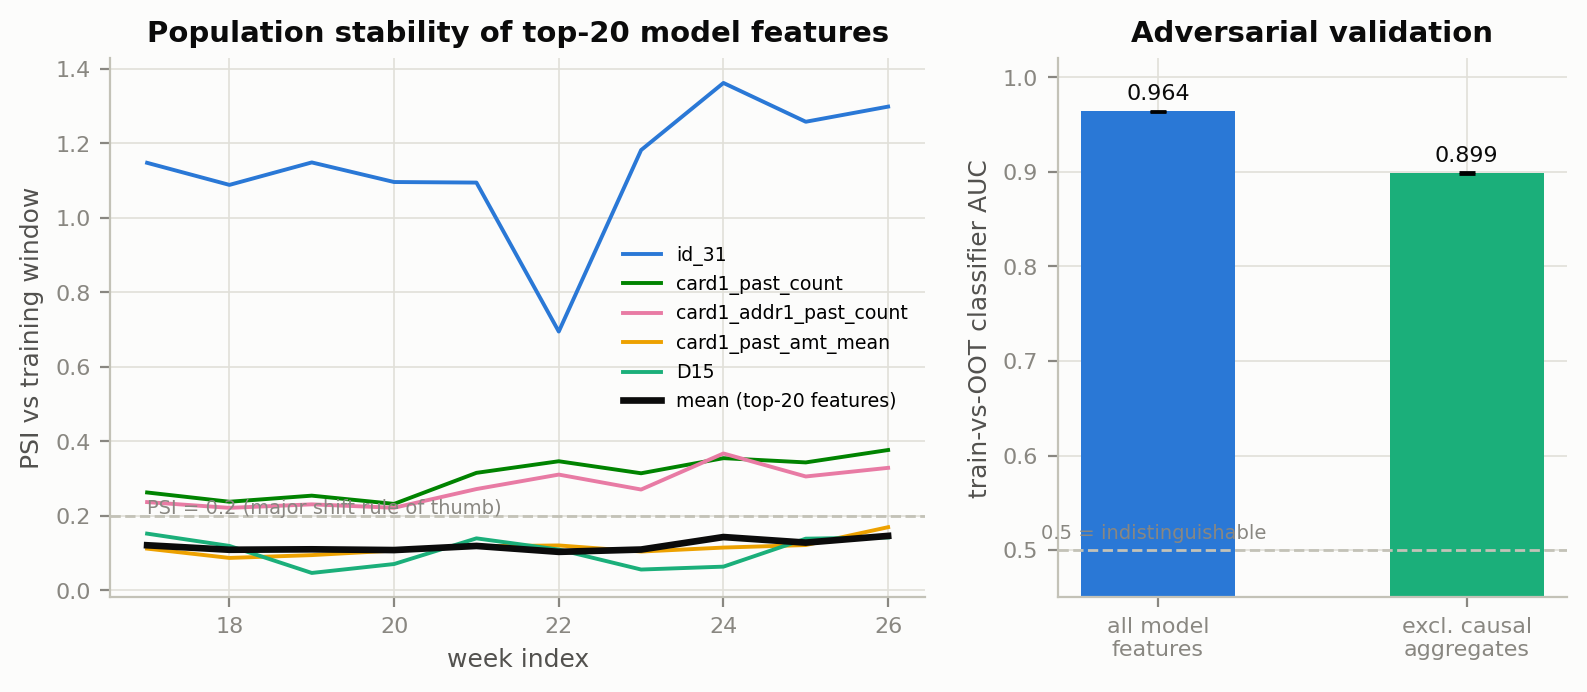

In [6]:
fig('figure_08_psi_adversarial')